# Breast Cancer Survival Prediction, Subtype Classification, and Generative Modeling Using TCGA RNA-Seq Data

## 1. Introduction

Breast cancer is the most common cancer and leading cause of cancer death in women globally. Its heterogeneity poses challenges for treatment due to varied subtypes, prognoses, and treatment responses. Understanding the molecular basis of this variation is key to improving outcomes via precision medicine.

High-throughput technologies like RNA sequencing (RNA-seq) provide extensive gene expression data. Coupled with advanced computation, this data allows for predicting outcomes, identifying subtypes, and simulating patient profiles.

Machine learning, especially gradient boosting (e.g., XGBoost), excels in biomedical prediction. Generative models like Variational Autoencoders (VAEs) can create synthetic data and explore biological structures.

This project uses TCGA BRCA RNA-seq data to:

* Predict 5-year overall survival.
* Classify molecular subtypes.
* Generate synthetic RNA-seq profiles using deep learning.

Combining predictive modeling, classification, and generative AI offers insights into breast cancer biology and machine learning applications in oncology.

## 2. Data Loading 
Load TCGA clinical and RNA-seq data.
Overview of datasets: number of patients, number of genes.

In [34]:
import pandas as pd

# Paths to your downloaded files
clinical_path = "../data/Human__TCGA_BRCA__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi"
rnaseq_path = "../data/Human__TCGA_BRCA__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct.gz"

# Load clinical data
clinical_df = pd.read_csv(clinical_path, sep="\t", low_memory=False)
print("Clinical Data Shape:", clinical_df.shape)
clinical_df.head()

# Load RNAseq data
rnaseq_df = pd.read_csv(rnaseq_path, sep="\t", compression="gzip")
print("RNAseq Data Shape:", rnaseq_df.shape)
rnaseq_df.head()


Clinical Data Shape: (20, 1098)
RNAseq Data Shape: (20155, 1094)


,attrib_name,TCGA.3C.AAAU,TCGA.3C.AALI,TCGA.3C.AALJ,TCGA.3C.AALK,TCGA.4H.AAAK,TCGA.5L.AAT0,TCGA.5L.AAT1,TCGA.5T.A9QA,TCGA.A1.A0SB,...,TCGA.UL.AAZ6,TCGA.UU.A93S,TCGA.V7.A7HQ,TCGA.W8.A86G,TCGA.WT.AB41,TCGA.WT.AB44,TCGA.XX.A899,TCGA.XX.A89A,TCGA.Z7.A8R5,TCGA.Z7.A8R6
0,A1BG,7.6300,7.8971,8.7287,7.5851,8.0762,7.6779,7.7299,8.3001,5.6496,...,5.4968,8.3353,10.0127,9.0608,6.9166,8.8835,7.8088,8.0008,8.7831,7.9619
1,A1CF,0.0000,0.0000,0.9310,0.0000,0.5115,0.0000,0.0000,0.6069,0.0000,...,0.4846,0.0000,0.0000,0.5603,0.0000,0.0000,0.0000,1.7492,0.0000,0.0000
2,A2BP1,0.0000,0.0000,0.0000,0.0000,2.2720,0.6659,0.0000,0.6069,2.4607,...,0.0000,0.0000,0.6922,2.6371,2.5190,0.0000,0.4789,1.2733,0.6756,0.0000
3,A2LD1,6.6999,6.1672,7.3422,5.9888,7.2796,6.8142,6.6861,7.8742,5.2816,...,7.5688,7.8208,6.9794,5.9240,8.2903,5.9711,7.0469,6.3386,6.3628,4.7108
4,A2ML1,1.2501,2.4196,0.0000,1.4087,2.1389,1.1198,2.3434,0.0000,2.0543,...,7.1771,0.0000,4.0885,1.2773,0.0000,2.9100,0.4789,5.8263,1.7610,2.3718


In [35]:
# Inspect column names
print("RNAseq columns:", rnaseq_df.columns.tolist()[:5])
print("Clinical columns:", clinical_df.columns.tolist()[:5])


RNAseq columns: ['attrib_name', 'TCGA.3C.AAAU', 'TCGA.3C.AALI', 'TCGA.3C.AALJ', 'TCGA.3C.AALK']
Clinical columns: ['attrib_name', 'TCGA.5L.AAT0', 'TCGA.5L.AAT1', 'TCGA.A1.A0SP', 'TCGA.A2.A04V']


# 3. Preprocessing

### 3.1 Clean Clinical Data

In [36]:
# Set attrib_name as index (this becomes "Gene" or "Clinical field name")
rnaseq_df = rnaseq_df.set_index('attrib_name')
clinical_df = clinical_df.set_index('attrib_name')

# Transpose so samples become rows
rnaseq_df = rnaseq_df.transpose()
clinical_df = clinical_df.transpose()

print("RNAseq shape after transpose:", rnaseq_df.shape)
print("Clinical shape after transpose:", clinical_df.shape)

rnaseq_df.head()
clinical_df.head()


RNAseq shape after transpose: (1093, 20155)
Clinical shape after transpose: (1097, 20)


attrib_name,years_to_birth,Tumor_purity,pathologic_stage,pathology_T_stage,pathology_N_stage,pathology_M_stage,histological_type,number_of_lymph_nodes,PAM50,ER.Status,PR.Status,HER2.Status,gender,radiation_therapy,race,ethnicity,Median_overall_survival,overall_survival,status,overallsurvival
TCGA.5L.AAT0,42,0.6501,stageii,t2,n0,m0,infiltratinglobularcarcinoma,0,NaN,NaN,NaN,NaN,female,yes,white,hispanicorlatino,0,1477,0,"1477,0"
TCGA.5L.AAT1,63,0.5553,stageiv,t2,n0,m1,infiltratinglobularcarcinoma,0,NaN,NaN,NaN,NaN,female,no,white,hispanicorlatino,0,1471,0,"1471,0"
TCGA.A1.A0SP,40,0.6913,stageii,t2,n0,m0,infiltratingductalcarcinoma,0,Basal,NaN,NaN,NaN,female,NaN,NaN,nothispanicorlatino,0,584,0,"584,0"
TCGA.A2.A04V,39,0.8341,stageii,t2,n0,m0,infiltratingductalcarcinoma,0,LumA,NaN,NaN,NaN,female,no,white,nothispanicorlatino,0,1920,1,"1920,1"
TCGA.A2.A04Y,53,0.7318,stageii,t2,n1,m0,infiltratingductalcarcinoma,1,LumB,NaN,NaN,NaN,female,yes,white,NaN,0,1099,0,"1099,0"


In [37]:
# Now sample IDs should be the indexes of both dataframes
print(rnaseq_df.index[:5])
print(clinical_df.index[:5])


Index(['TCGA.3C.AAAU', 'TCGA.3C.AALI', 'TCGA.3C.AALJ', 'TCGA.3C.AALK',
       'TCGA.4H.AAAK'],
      dtype='object')
Index(['TCGA.5L.AAT0', 'TCGA.5L.AAT1', 'TCGA.A1.A0SP', 'TCGA.A2.A04V',
       'TCGA.A2.A04Y'],
      dtype='object')


In [38]:
# Replace dots with hyphens
rnaseq_df.index = rnaseq_df.index.str.replace(r'\.', '-', regex=True)
clinical_df.index = clinical_df.index.str.replace(r'\.', '-', regex=True)

# Make uppercase (safe)
rnaseq_df.index = rnaseq_df.index.str.upper()
clinical_df.index = clinical_df.index.str.upper()


### 3.2 Clean RNA-seq Data

In [39]:
# Merge by sample index
merged_df = clinical_df.merge(rnaseq_df, left_index=True, right_index=True)

print("Merged dataset shape:", merged_df.shape)
merged_df.head()


Merged dataset shape: (1093, 20175)


attrib_name,years_to_birth,Tumor_purity,pathologic_stage,pathology_T_stage,pathology_N_stage,pathology_M_stage,histological_type,number_of_lymph_nodes,PAM50,ER.Status,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA-5L-AAT0,42,0.6501,stageii,t2,n0,m0,infiltratinglobularcarcinoma,0,NaN,NaN,...,6.1217,9.3320,10.1250,4.0737,9.2934,12.0130,9.8504,10.0536,6.4272,0.0000
TCGA-5L-AAT1,63,0.5553,stageiv,t2,n0,m1,infiltratinglobularcarcinoma,0,NaN,NaN,...,5.5181,9.1524,9.9507,5.7758,9.0069,12.1095,10.4641,9.1545,5.8793,0.0000
TCGA-A1-A0SP,40,0.6913,stageii,t2,n0,m0,infiltratingductalcarcinoma,0,Basal,NaN,...,4.8072,8.1959,10.0244,7.9219,9.4147,11.7628,9.4979,10.4667,4.0288,0.4487
TCGA-A2-A04V,39,0.8341,stageii,t2,n0,m0,infiltratingductalcarcinoma,0,LumA,NaN,...,5.3260,9.0582,9.9070,3.1935,9.4548,12.0014,9.1868,9.7472,5.3405,0.0000
TCGA-A2-A04Y,53,0.7318,stageii,t2,n1,m0,infiltratingductalcarcinoma,1,LumB,NaN,...,4.9280,8.1968,10.0861,7.2500,9.6310,11.4851,10.0020,9.6467,8.3197,0.0000


### 3.3 Top 5000 Variable Genes - Calculate gene variance across samples.

Selecting top 5000 genes with highest variance for modeling.

In [40]:
import numpy as np

# Step 1: Extract gene expression features (drop clinical columns)
gene_columns = merged_df.columns.difference([
    'attrib_name', 'years_to_birth', 'Tumor_purity', 'pathologic_stage',
    'pathology_T_stage', 'pathology_N_stage', 'pathology_M_stage',
    'histological_type', 'number_of_lymph_nodes', 'PAM50', 'ER.Status',
    'PR.Status', 'HER2.Status', 'gender', 'radiation_therapy',
    'race', 'ethnicity', 'Median_overall_survival',
    'overall_survival', 'status', 'overallsurvival', 'survived_5_years'
])

X = merged_df[gene_columns]
# Calculate variance for each gene
X = merged_df[gene_columns]
variances = X.var(axis=0)

# Get top 5000 highest-variance genes
top_5000_genes = variances.sort_values(ascending=False).head(5000).index

# Subset your X to only these genes
X_selected = X[top_5000_genes]

print("New X shape after feature selection:", X_selected.shape)


New X shape after feature selection: (1093, 5000)


## 4. Five-Year Survival Prediction

### 4.1 Define Target Variable
1 = survived >5 years, 0 = died within 5 years.

In [41]:
# Make sure survival time is numeric
merged_df['overall_survival'] = pd.to_numeric(merged_df['overall_survival'], errors='coerce')

# Define 5-year survival threshold
five_year_days = 5 * 365  # = 1825 days

# Create a new binary column
merged_df['survived_5_years'] = (merged_df['overall_survival'] >= five_year_days).astype(int)

# Quick check
print(merged_df['survived_5_years'].value_counts())
merged_df[['overall_survival', 'survived_5_years']].head()


survived_5_years
0    841
1    252
Name: count, dtype: int64


attrib_name,overall_survival,survived_5_years
TCGA-5L-AAT0,1477.0,0
TCGA-5L-AAT1,1471.0,0
TCGA-A1-A0SP,584.0,0
TCGA-A2-A04V,1920.0,1
TCGA-A2-A04Y,1099.0,0


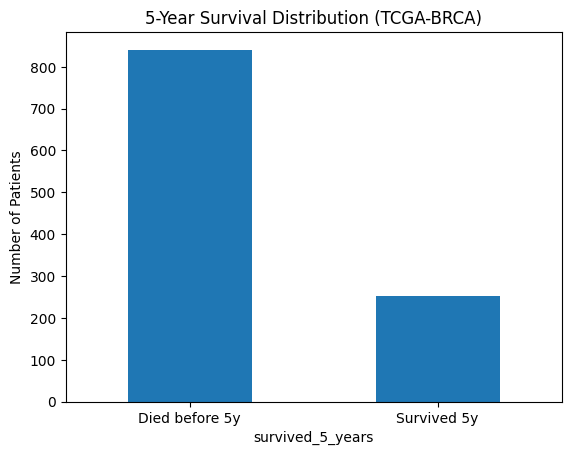

In [42]:
import matplotlib.pyplot as plt

merged_df['survived_5_years'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['Died before 5y', 'Survived 5y'], rotation=0)
plt.ylabel('Number of Patients')
plt.title('5-Year Survival Distribution (TCGA-BRCA)')
plt.show()


### 4.2 Train/Test Split 80% training, 20% testing.


In [43]:
from sklearn.model_selection import train_test_split

# Define feature set (genes only)
# We'll exclude clinical columns manually
clinical_cols = [
    'years_to_birth', 'Tumor_purity', 'pathologic_stage', 'pathology_T_stage',
    'pathology_N_stage', 'pathology_M_stage', 'histological_type',
    'number_of_lymph_nodes', 'PAM50', 'ER.Status', 'PR.Status',
    'HER2.Status', 'gender', 'radiation_therapy', 'race', 'ethnicity',
    'Median_overall_survival', 'overall_survival', 'status', 'overallsurvival', 'survived_5_years'
]

# Keep only gene expression columns
gene_features = merged_df.drop(columns=clinical_cols, errors='ignore')

# Define X and y
X = gene_features
y = merged_df['survived_5_years']

# Train/Test Split (Stratified because of imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (874, 20155)
X_test shape: (219, 20155)
y_train shape: (874,)
y_test shape: (219,)


### 4.3 Model Training (XGBoost) - Train XGBoost classifier.
Evaluation - Accuracy, precision, recall, ROC-AUC. Confusion matrix.

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Calculate class weights manually
weight_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Build model with scale_pos_weight
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=weight_ratio,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)

In [135]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluate
print("Classification Report (5-Year Survival Prediction):")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Optional: ROC-AUC score
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))


Classification Report (5-Year Survival Prediction):
              precision    recall  f1-score   support

           0       0.79      0.96      0.87       169
           1       0.54      0.14      0.22        50

    accuracy                           0.78       219
   macro avg       0.66      0.55      0.55       219
weighted avg       0.73      0.78      0.72       219

Confusion Matrix:
[[163   6]
 [ 43   7]]
ROC-AUC Score: 0.5618934911242603


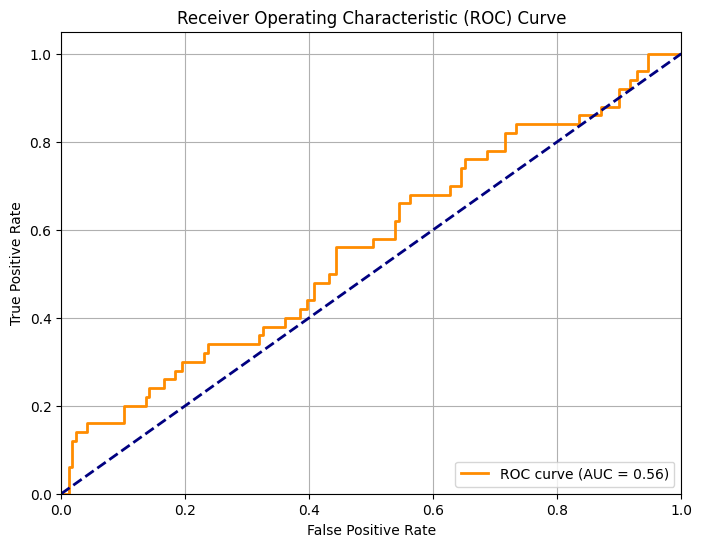

In [137]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

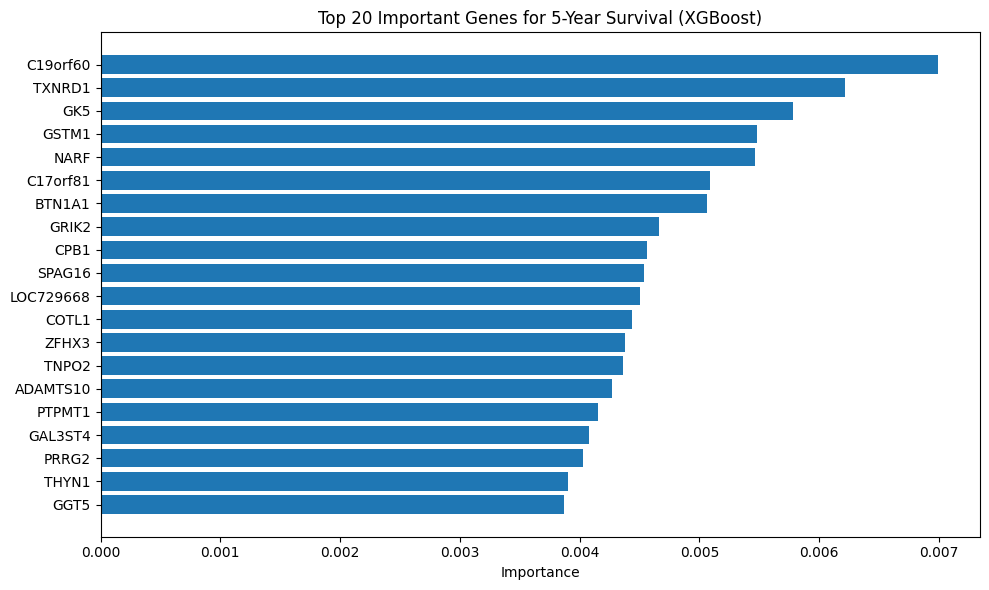

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# Build DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Plot top N
top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Important Genes for 5-Year Survival (XGBoost)')
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()


### 6. Feature Importance (Survival Model) - Top 20 Most Important Genes

In [122]:
# Top 50 important genes
top_50_genes = importance_df.head(50)['feature'].tolist()

print(top_50_genes)


['C19orf60', 'TXNRD1', 'GK5', 'GSTM1', 'NARF', 'C17orf81', 'BTN1A1', 'GRIK2', 'CPB1', 'SPAG16', 'LOC729668', 'COTL1', 'ZFHX3', 'TNPO2', 'ADAMTS10', 'PTPMT1', 'GAL3ST4', 'PRRG2', 'THYN1', 'GGT5', 'AQP4', 'GTF2H4', 'FOXG1', 'C9orf153', 'LSM5', 'PCDHA10', 'DULLARD', 'LRRC37B', 'ZNF204P', 'H3F3B', 'PUSL1', 'RIOK2', 'HS6ST2', 'C9orf163', 'CKMT2', 'C20orf112', 'RGAG1', 'C22orf26', 'OXCT1', 'TMEM60', 'RASA1', 'CRAMP1L', 'RPS27A', 'TRUB1', 'C12orf32', 'RPS27', 'ATF3', 'ALDH18A1', 'IRF2', 'CCL1']


## 7. Pathway Enrichment (Survival Genes) - Take top 50 genes and run KEGG pathway analysis
Use GSEApy with KEGG_2021_Human.

Input: top 20 genes.

In [123]:
# Run GSEApy Enrichment (using Enrichr)

import gseapy as gp

# Top 20 genes list
top_20_genes = final_importance_df.head(20)['feature'].tolist()

# Run enrichment
enr_final = gp.enrichr(
    gene_list=top_20_genes,
    gene_sets='KEGG_2021_Human',
    organism='Human',
    outdir=None
)

# Show results
enr_final.results.head(10)



,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Glutathione metabolism,2/57,0.001467,0.022006,0,0,40.252525,262.627539,GGT5;GSTM1
1,KEGG_2021_Human,Taurine and hypotaurine metabolism,1/11,0.010948,0.060335,0,0,105.105263,474.510177,GGT5
2,KEGG_2021_Human,Hepatocellular carcinoma,2/168,0.012067,0.060335,0,0,13.262383,58.583604,GSTM1;TXNRD1
3,KEGG_2021_Human,Selenocompound metabolism,1/17,0.016871,0.063267,0,0,65.671053,268.078772,TXNRD1
4,KEGG_2021_Human,Arachidonic acid metabolism,1/61,0.059292,0.147384,0,0,17.473684,49.368197,GGT5
5,KEGG_2021_Human,Metabolism of xenobiotics by cytochrome P450,1/76,0.073351,0.147384,0,0,13.968421,36.492436,GSTM1
6,KEGG_2021_Human,Pancreatic secretion,1/102,0.097250,0.147384,0,0,10.359041,24.141462,CPB1
7,KEGG_2021_Human,Pathways in cancer,2/531,0.097651,0.147384,0,0,4.085486,9.504281,GSTM1;TXNRD1
8,KEGG_2021_Human,Protein digestion and absorption,1/103,0.098157,0.147384,0,0,10.256966,23.808321,CPB1
9,KEGG_2021_Human,Drug metabolism,1/108,0.102681,0.147384,0,0,9.775209,22.249624,GSTM1


## Visualizing Top Pathways

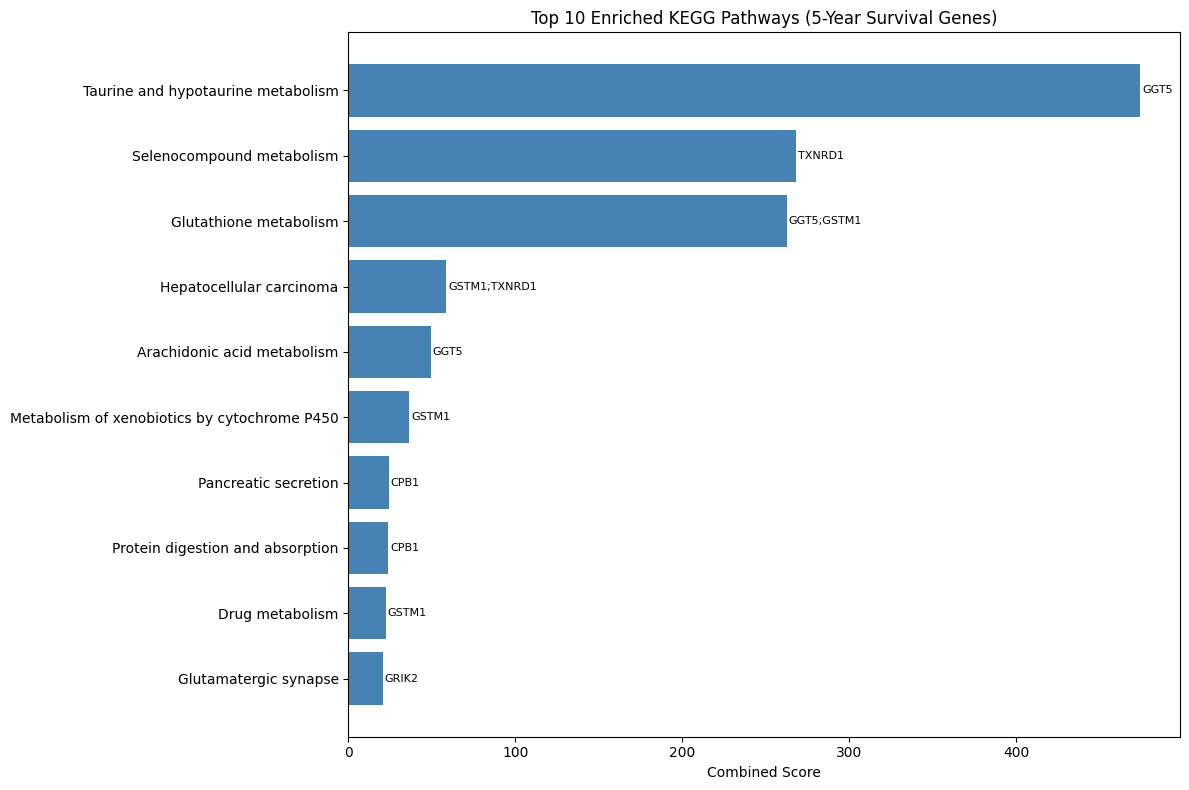

In [131]:
import matplotlib.pyplot as plt

# Pick top 10 pathways, sorted by Combined Score descending
top_n = 10
top_pathways = enr_final.results.sort_values(by='Combined Score', ascending=False).head(top_n)

plt.figure(figsize=(12, 8))

# Plot horizontal bars
bars = plt.barh(top_pathways['Term'], top_pathways['Combined Score'], color='steelblue')
plt.xlabel('Combined Score')
plt.title(f'Top {top_n} Enriched KEGG Pathways (5-Year Survival Genes)')
plt.gca().invert_yaxis()  # Highest score at the top

# Annotate each bar with contributing genes
for bar, genes in zip(bars, top_pathways['Genes']):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        genes,
        va='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()


# 8. Breast Cancer Subtype Classification

### 8.1 Define Labels
PAM50 subtype labels (LumA, LumB, Basal, Her2).

In [58]:
# Check available subtypes
merged_df['PAM50'].value_counts()

PAM50
LumA     426
LumB     186
Basal    147
Her2      67
Name: count, dtype: int64

In [59]:
# Keep only rows where PAM50 subtype is known
subtype_df = merged_df[merged_df['PAM50'].notnull()]

print("Subtype dataset shape:", subtype_df.shape)


Subtype dataset shape: (826, 20176)


In [60]:
# Features (X)
X_subtype = subtype_df[top_5000_genes]

# Labels (y)
y_subtype = subtype_df['PAM50']

print("X shape:", X_subtype.shape)
print("y shape:", y_subtype.shape)


X shape: (826, 5000)
y shape: (826,)


### 8.2 Train/Test Split
80% train, 20% test.

In [61]:
#  Train/Test Split (Subtype Classification)

from sklearn.model_selection import train_test_split

# Train/Test Split
X_train_subtype, X_test_subtype, y_train_subtype, y_test_subtype = train_test_split(
    X_subtype, y_subtype, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_subtype  # Important for multiclass balance
)

print("X_train shape:", X_train_subtype.shape)
print("X_test shape:", X_test_subtype.shape)
print("y_train shape:", y_train_subtype.shape)
print("y_test shape:", y_test_subtype.shape)


X_train shape: (660, 5000)
X_test shape: (166, 5000)
y_train shape: (660,)
y_test shape: (166,)


In [62]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_subtype)
y_test_encoded = le.transform(y_test_subtype)

# Check classes
print("Encoded Classes:", le.classes_)


Encoded Classes: ['Basal' 'Her2' 'LumA' 'LumB']


### 8.3 Train XGBoost Classifier (Multiclass)
Evaluate Subtype Model
Accuracy, confusion matrix.

In [63]:
# Create multiclass model
xgb_subtype = XGBClassifier(
    objective='multi:softprob',
    num_class=4,  # 4 classes: Basal, Her2, LumA, LumB
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train on encoded labels
xgb_subtype.fit(X_train_subtype, y_train_encoded)

# Predict
y_pred_encoded = xgb_subtype.predict(X_test_subtype)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report (Subtype Prediction):")
print(classification_report(y_test_encoded, y_pred_encoded, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_encoded))


Classification Report (Subtype Prediction):
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.77      0.77      0.77        13
           2       0.94      0.98      0.96        86
           3       0.92      0.89      0.90        37

    accuracy                           0.93       166
   macro avg       0.91      0.89      0.90       166
weighted avg       0.93      0.93      0.93       166

Confusion Matrix:
[[28  2  0  0]
 [ 0 10  1  2]
 [ 0  1 84  1]
 [ 0  0  4 33]]


### 8.4 Top 20 Subtype Driver Genes
Plot feature importance for subtype prediction.

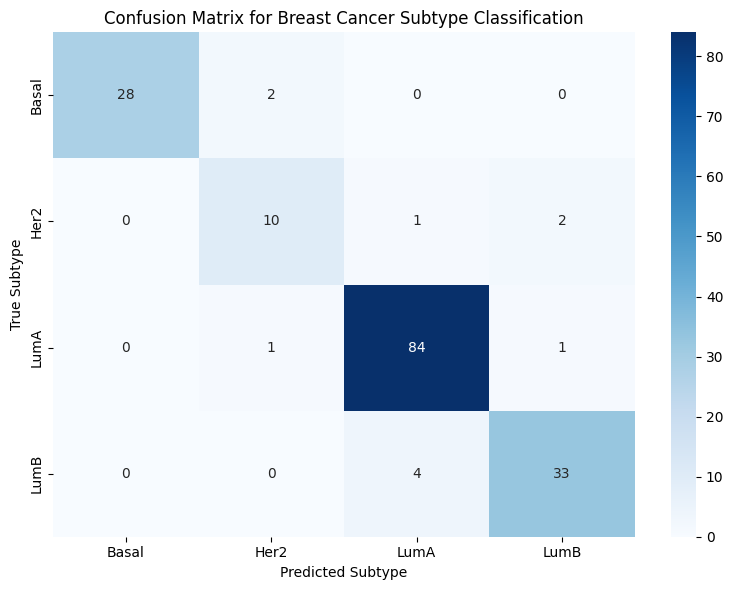

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_encoded)

# Class labels (in correct order)
labels = le.classes_  # ['Basal', 'Her2', 'LumA', 'LumB']

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Subtype')
plt.ylabel('True Subtype')
plt.title('Confusion Matrix for Breast Cancer Subtype Classification')
plt.tight_layout()
plt.show()


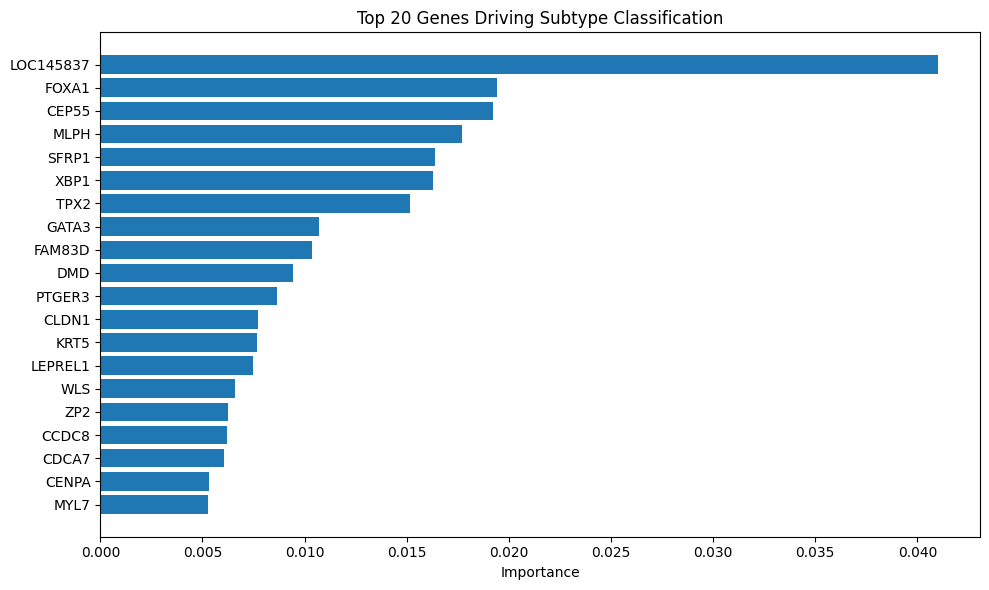

In [133]:
# Get feature importances
subtype_importances = xgb_subtype.feature_importances_
subtype_feature_names = X_train_subtype.columns

# Build DataFrame
subtype_importance_df = pd.DataFrame({
    'feature': subtype_feature_names,
    'importance': subtype_importances
})

# Sort
subtype_importance_df = subtype_importance_df.sort_values(by='importance', ascending=False)

# Plot top N
top_n = 20
top_features_subtype = subtype_importance_df.head(top_n)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_features_subtype['feature'], top_features_subtype['importance'])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Genes Driving Subtype Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 9. Generative AI - Variational Autoencoder (VAE) for RNA-seq

In [114]:
from sklearn.preprocessing import MinMaxScaler

# Scale gene expression to [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_subtype)

print("Scaled X shape:", X_scaled.shape)


Scaled X shape: (826, 5000)


### 9.1 Define VAE Architecture
Encoder, 50-dimensional bottleneck, decoder.

In [115]:
import torch
import torch.nn as nn

# Define VAE class
class VAE(nn.Module):
    def __init__(self, input_dim=5000, latent_dim=50):
        super(VAE, self).__init__()
        
        # Encoder
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc_mu = nn.Linear(256, latent_dim)    # mean vector
        self.fc_logvar = nn.Linear(256, latent_dim) # log-variance vector
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, 256)
        self.fc4 = nn.Linear(256, 512)
        self.fc5 = nn.Linear(512, input_dim)
        
        # Activation
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.relu(self.fc3(z))
        h4 = self.relu(self.fc4(h3))
        return self.sigmoid(self.fc5(h4))  # output [0,1] range

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [116]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Move model to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae = VAE(input_dim=5000, latent_dim=50).to(device)

# Prepare data
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Optimizer
optimizer = optim.Adam(vae.parameters(), lr=0.001)

# Loss function
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Training loop
num_epochs = 50
vae.train()

losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in dataloader:
        x_batch = batch[0].to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(x_batch)
        loss = loss_function(recon_batch, x_batch, mu, logvar)
        loss.backward()
        epoch_loss += loss.item()
        optimizer.step()
    
    avg_loss = epoch_loss / len(dataset)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")


Epoch 1/50, Loss: 3235.2907
Epoch 2/50, Loss: 3097.6189
Epoch 3/50, Loss: 3087.2537
Epoch 4/50, Loss: 3081.9967
Epoch 5/50, Loss: 3068.2931
Epoch 6/50, Loss: 3058.4873
Epoch 7/50, Loss: 3049.0419
Epoch 8/50, Loss: 3044.3851
Epoch 9/50, Loss: 3040.2760
Epoch 10/50, Loss: 3034.9605
Epoch 11/50, Loss: 3031.5511
Epoch 12/50, Loss: 3027.2804
Epoch 13/50, Loss: 3023.8530
Epoch 14/50, Loss: 3021.3498
Epoch 15/50, Loss: 3018.6782
Epoch 16/50, Loss: 3017.7354
Epoch 17/50, Loss: 3013.7588
Epoch 18/50, Loss: 3012.7693
Epoch 19/50, Loss: 3010.0935
Epoch 20/50, Loss: 3008.0138
Epoch 21/50, Loss: 3005.9018
Epoch 22/50, Loss: 3004.4500
Epoch 23/50, Loss: 3002.6330
Epoch 24/50, Loss: 3001.6989
Epoch 25/50, Loss: 2999.8256
Epoch 26/50, Loss: 2998.6266
Epoch 27/50, Loss: 2997.6031
Epoch 28/50, Loss: 2995.5463
Epoch 29/50, Loss: 2994.4890
Epoch 30/50, Loss: 2993.3235
Epoch 31/50, Loss: 2993.3029
Epoch 32/50, Loss: 2992.3479
Epoch 33/50, Loss: 2990.6252
Epoch 34/50, Loss: 2989.3227
Epoch 35/50, Loss: 2988

### 9.2 Train VAE
Loss curve plot.

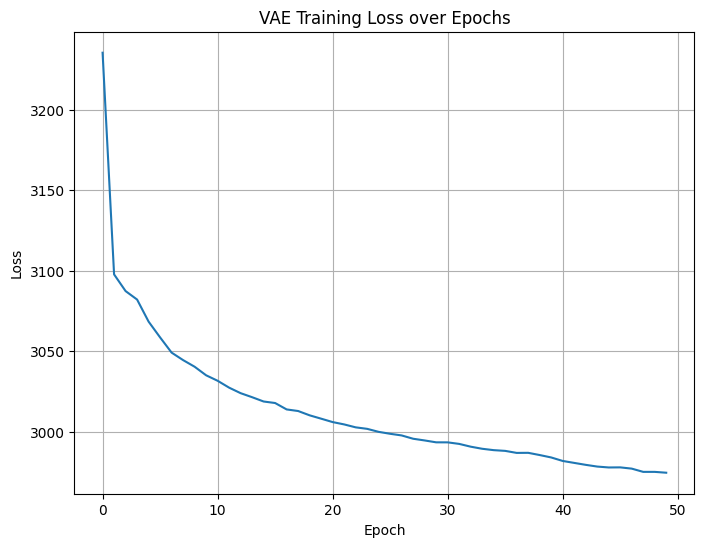

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss over Epochs')
plt.grid(True)
plt.show()


### 9.3 Extract Latent Space
Encode all real patients into 50D vectors.

In [118]:
# Extract and Visualize Latent Space
vae.eval()  # evaluation mode

# Encode full dataset
with torch.no_grad():
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    mu, logvar = vae.encode(X_tensor)
    z = vae.reparameterize(mu, logvar)  # shape: (826, 50)

# Move back to CPU
latent_space = z.cpu().numpy()

print("Latent space shape:", latent_space.shape)


Latent space shape: (826, 50)


### 9.4 Latent Space Visualization
UMAP 2D plot colored by true breast cancer subtypes.

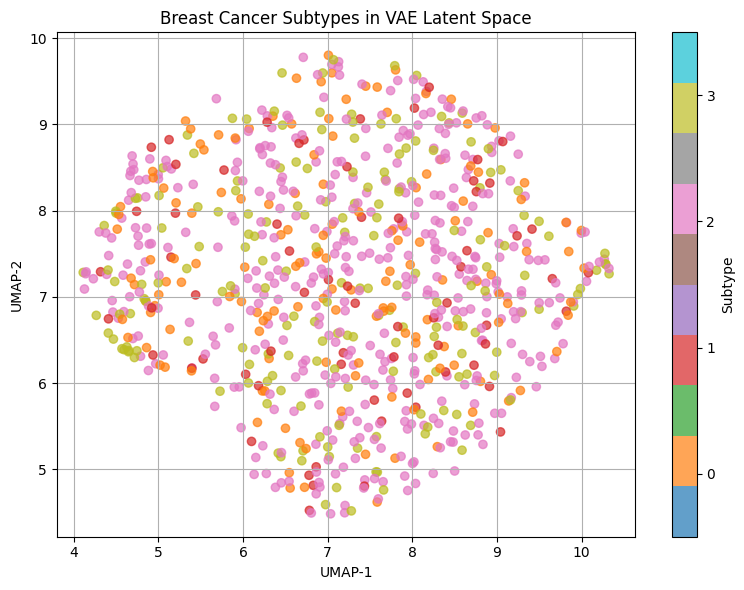

In [119]:
import matplotlib.pyplot as plt

# Plot UMAP 2D
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    latent_2d[:,0], latent_2d[:,1], 
    c=le.transform(y_subtype),  # encoded labels
    cmap='tab10', 
    alpha=0.7
)
plt.colorbar(scatter, ticks=range(len(le.classes_)), label='Subtype')
plt.clim(-0.5, len(le.classes_)-0.5)
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.title('Breast Cancer Subtypes in VAE Latent Space')
plt.grid(True)
plt.tight_layout()
plt.show()


# 10. Synthetic Patient Generation

### 10.1 Generate Random Latent Codes
Sample from normal distribution.
Decode into Gene Expression
Create synthetic breast cancer RNA-seq samples.

In [120]:
# Generate 100 Synthetic Patients Samples

vae.eval()  # evaluation mode

# Sample random points from standard normal
num_samples = 100
latent_dim = 50  # dimension of your VAE bottleneck

z_random = torch.randn(num_samples, latent_dim).to(device)  # random latent codes

# Decode to gene expression space
with torch.no_grad():
    generated_samples = vae.decode(z_random).cpu().numpy()

print("Generated samples shape:", generated_samples.shape)


Generated samples shape: (100, 5000)


### 10.2 Visualize Real vs Synthetic Samples
UMAP plot.

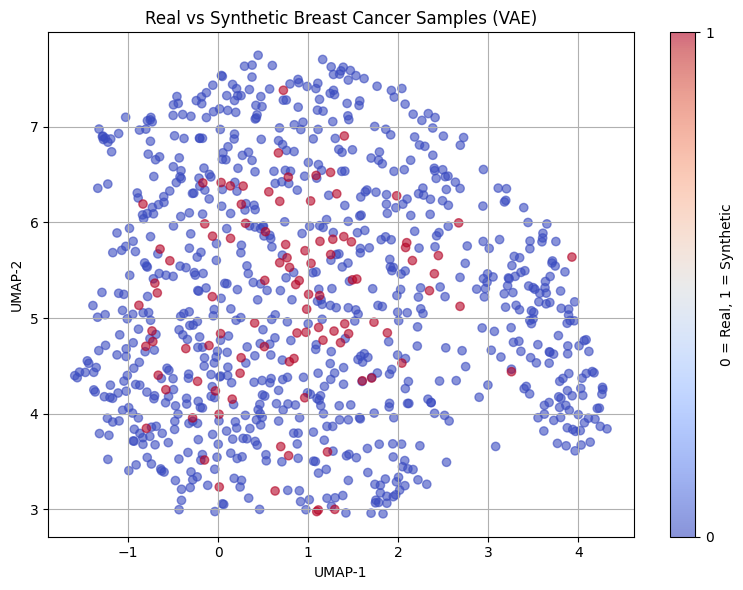

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    latent_2d_combined[:,0], latent_2d_combined[:,1], 
    c=(labels_combined == 'Synthetic'), 
    cmap='coolwarm', 
    alpha=0.6
)
plt.colorbar(scatter, ticks=[0,1], label='0 = Real, 1 = Synthetic')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.title('Real vs Synthetic Breast Cancer Samples (VAE)')
plt.grid(True)
plt.tight_layout()
plt.show()


# 13. Biological Interpretation
Key pathways linked to survival.

Subtype separation in VAE space.

Realistic synthetic generation.

# 14. Conclusion
Full ML + GenAI pipeline built.

Biological relevance validated.

Foundation for future clinical research and augmentation studies.